## Harris corner detection

Juan Diego Perez Navarro  
T00067699  
Universidad Tecnológica de Bolívar

In this activity we will implement a Harris corner detection algorithm. Then, we will use the OpenCV Harris corner detection function.

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

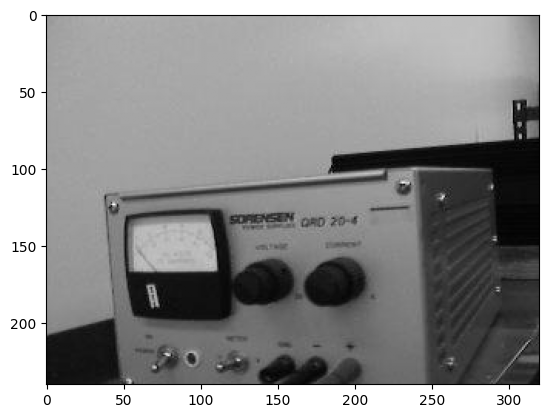

In [4]:
IMAGE_URL = 'https://github.com/agmarrugo/computer-vision-utb/raw/main/data/test000.jpg'
image_data = "images/test000.jpg"

urllib.request.urlretrieve(IMAGE_URL, image_data)

img = cv2.imread(image_data)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Display image
plt.imshow(img_gray, cmap='gray')
plt.show()


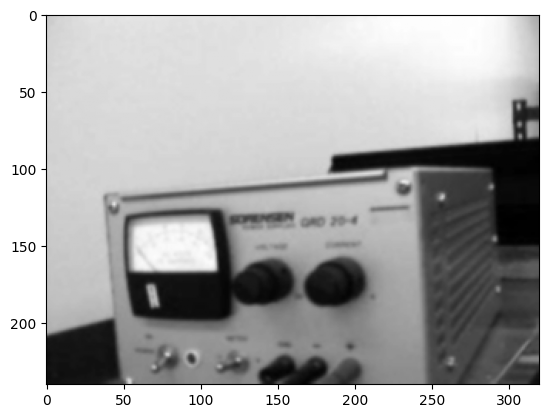

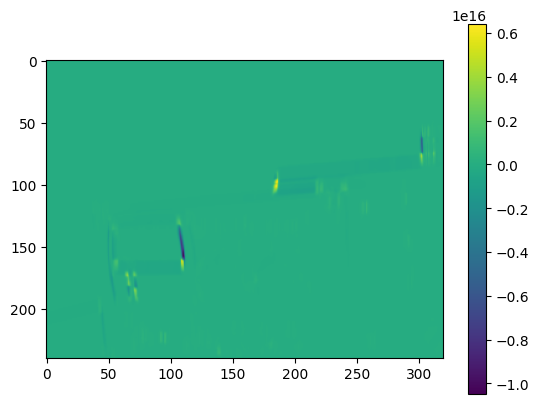

In [5]:
# Apply Gaussian blur


sigma = 1
img_blur = cv2.GaussianBlur(img_gray, (13, 13), sigma)

plt.imshow(img_blur, cmap="gray")
plt.show()

# Compute the gradient components
Gx = cv2.Sobel(img_blur, cv2.CV_64F, 1, 0, ksize=5)
Gy = cv2.Sobel(img_blur, cv2.CV_64F, 0, 1, ksize=5)

# Compute the outer product g'g at each pixel
Gxx = Gx * Gx
Gxy = Gx * Gy
Gyy = Gy * Gy

# Size of neighborhood over which to compute corner features.
N = 13

w = np.ones(N)  # The neighborhood

# Sum the G's over the window size.
A11 = cv2.filter2D(Gxx, cv2.CV_64F, w)
A12 = cv2.filter2D(Gxy, cv2.CV_64F, w)
A22 = cv2.filter2D(Gyy, cv2.CV_64F, w)

# At each pixel (x,y), we have the 2x2 matrix
#  [A11(x,y) A12(x,y)
#   A21(x,y) A22(x,y)]
# Of course, A21 = A12.

# Compute the interest score: det(A) - alpha * trace(A)^2
alpha = 0.06
detA = A11 * A22 - A12**2  # Computes det(A) at each pixel
traceA = A11 + A22  # Computer trace(A) at each pixel
s = detA - alpha * traceA**2  # The interest score


plt.imshow(s)
plt.colorbar()
plt.show()


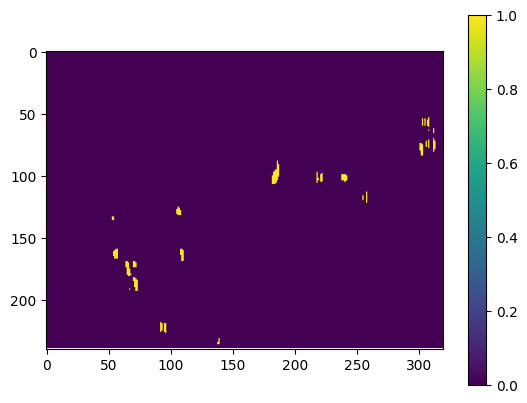

In [6]:
# Let's threshold the result

s_thresh = s > np.max(s) * 0.07

plt.imshow(s_thresh)
plt.colorbar()
plt.show()

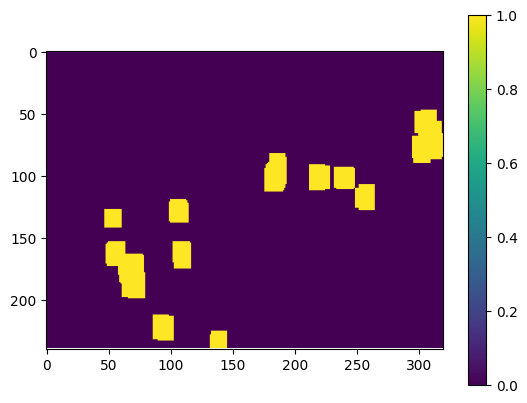

In [7]:
from scipy import ndimage as ndi
# Detect white blobs
# ret, thImg = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Remove unwanted noise
kernel = np.ones((9, 9), np.uint8)
# s_dilated = cv2.dilate(s_thresh, kernel, iterations = 1)

# r = N
# Let's dilate the image for non-maxima supression
s_dilated = ndi.maximum_filter(s_thresh, size=N, mode="constant")

plt.imshow(s_dilated)
plt.colorbar()
plt.show()

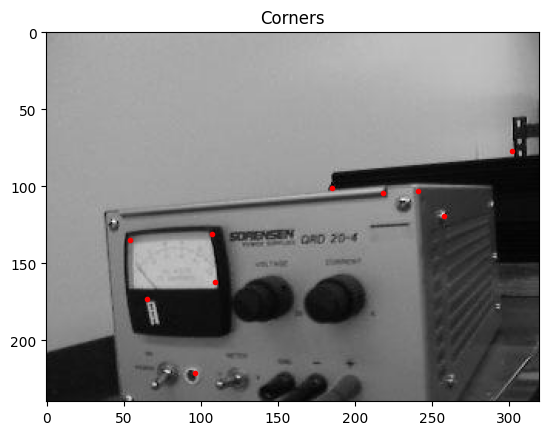

In [8]:
from skimage.feature import peak_local_max

# Find local maxima within each neighborhood N

coordinates = peak_local_max(s * s_thresh, min_distance=N)

plt.imshow(img, cmap="gray")
plt.plot(coordinates[:, 1], coordinates[:, 0], "r.")
plt.title("Corners")
plt.show()

## TODO

Use the OpenCV ``cv2.cornerHarris()`` function to detect corners on the above image and try it on an additional image. Read the documentation of the function and [here's an example](https://opencv24-python-tutorials.readthedocs.io/en/latest/py_tutorials/py_feature2d/py_features_harris/py_features_harris.html).

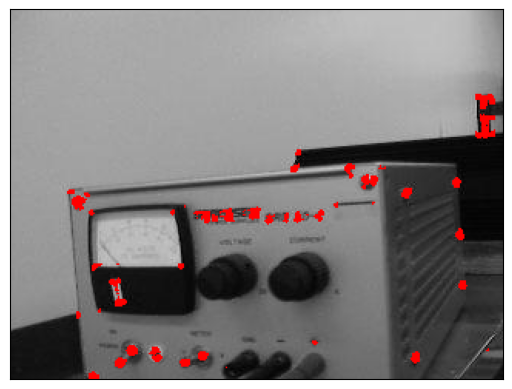

In [37]:
img = cv2.imread(image_data)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

output = cv2.cornerHarris(img_gray, blockSize=4, ksize=3, k=0.06)
img[output > 0.01 * output.max()] = [255, 0, 0]
plt.imshow(img, cmap="gray")
plt.xticks([]), plt.yticks([])
plt.show()

### Bonus

Detect corners on another version of the image and use a correlation approach to match the features between the two images as shown in the image below.

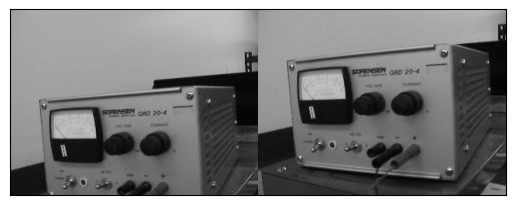

In [55]:
# Bonus

IMAGE_URL = "https://github.com/agmarrugo/computer-vision-utb/raw/main/data/test012.jpg"
image_data2 = "images/test012.jpg"

urllib.request.urlretrieve(IMAGE_URL, image_data2)

img1 = cv2.imread(image_data)
img_gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)

img2 = cv2.imread(image_data2)
img_gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

img = np.concatenate((img1, img2), axis=1)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
output = cv2.cornerHarris(img_gray, blockSize=4, ksize=3, k=0.06)

plt.imshow(img, cmap="gray")
plt.xticks([]), plt.yticks([])
plt.show()

In [65]:
def get_patch(img: cv2.Mat, y: int, x: int, patch_size: int = 11) -> cv2.Mat:
    h, w = img.shape
    half = patch_size // 2
    y_min = max(0, y - half)
    y_max = min(h, y + half + 1)
    x_min = max(0, x - half)
    x_max = min(w, x + half + 1)
    patch = img[y_min:y_max, x_min:x_max]
    return patch


def normalized_cross_correlation(patch1: cv2.Mat, patch2: cv2.Mat) -> float:
    if patch1.shape != patch2.shape:
        return -1

    patch1_norm = (patch1 - np.mean(patch1)) / (np.std(patch1) + 1e-7)
    patch2_norm = (patch2 - np.mean(patch2)) / (np.std(patch2) + 1e-7)
    corr = np.sum(patch1_norm * patch2_norm) / (patch1.size)
    return corr

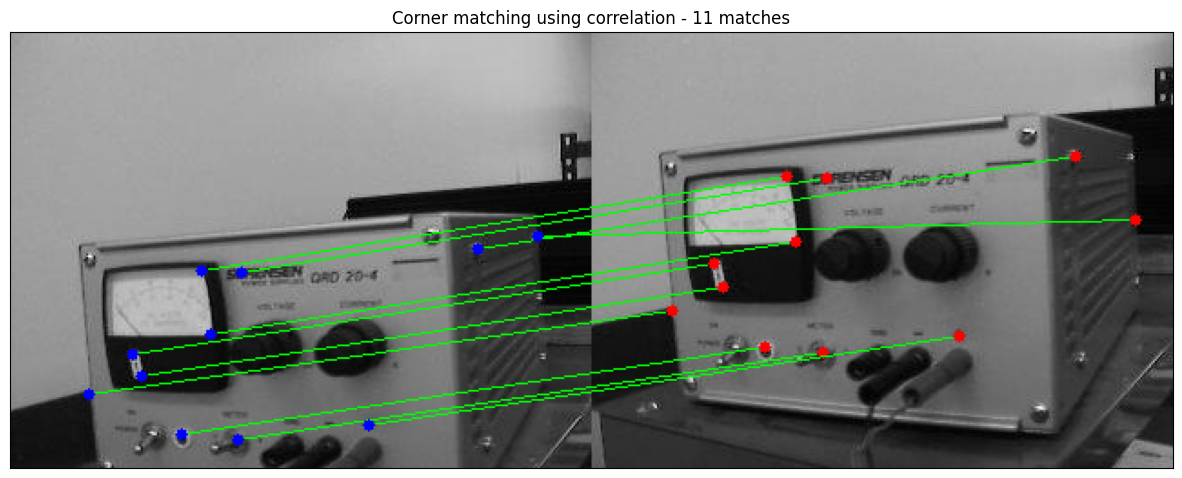

In [69]:
CORRELATION_TRESHOLD = 0.8

corners1 = cv2.cornerHarris(img_gray1, blockSize=4, ksize=3, k=0.06)
corners2 = cv2.cornerHarris(img_gray2, blockSize=4, ksize=3, k=0.06)

threshold1 = 0.01 * corners1.max()
threshold2 = 0.01 * corners2.max()

corner_coords1 = peak_local_max(corners1, min_distance=10, threshold_abs=threshold1)
corner_coords2 = peak_local_max(corners2, min_distance=10, threshold_abs=threshold2)

matches = []
for i, (y1, x1) in enumerate(corner_coords1):
    patch1 = get_patch(img_gray1, y1, x1)
    
    best_corr = -1
    best_match = None
    
    for j, (y2, x2) in enumerate(corner_coords2):
        patch2 = get_patch(img_gray2, y2, x2)
        
        corr = normalized_cross_correlation(patch1, patch2)
        
        if corr > best_corr:
            best_corr = corr
            best_match = (y2, x2, j)
    
    if best_corr > CORRELATION_TRESHOLD:
        matches.append((y1, x1, best_match[0], best_match[1], best_corr))

img1_width = img1.shape[1]

img_copy = img.copy()

for y1, x1, y2, x2, corr in matches:
    color = (0, 255, 0)
    cv2.line(img_copy, (x1, y1), (x2 + img1_width, y2), color, 1)
    cv2.circle(img_copy, (x1, y1), 3, (255, 0, 0), -1)
    cv2.circle(img_copy, (x2 + img1_width, y2), 3, (0, 0, 255), -1)

plt.figure(figsize=(15, 10))
plt.imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))
plt.title(f"Corner matching using correlation - {len(matches)} matches")
plt.xticks([]), plt.yticks([])
plt.show()